<a href="https://colab.research.google.com/github/lenmecc/miniature-enigma/blob/main/genetico_V7_vd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install deap gurobipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.9/14.9 MB 75.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.9/866.9 kB 50.0 MB/s eta 0:00:00


📥 Cargando datasets históricos...


/tmp/ipykernel_1232/4110973572.py:46: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')
/tmp/ipykernel_1232/4110973572.py:46: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')



═════════════════════════════════════════════════════════════════
 📊 RESUMEN DE VARIABLES CALCULADAS (DATASETS REALES)
═════════════════════════════════════════════════════════════════
Horizonte de Planeación (T) : 26 semanas
Fecha de Inicio             : 2024-01-01

[ PARÁMETROS FÍSICOS DE LA PRESA ]
Capacidad Máxima (S_max)    : 3,387,000.00 TCM
Límite de Sequía (S_min)    : 846,750.00 TCM
Volumen Inicial (S_inicial) : 581,232.10 TCM

[ ESPACIO DE DECISIÓN (HEURÍSTICO / CUÁNTICO) ]
Mediana del Flujo Histórico : 14,470.90 TCM
Salto Base (delta_u)        : 3,617.73 TCM
Ajuste Máximo Permitido     : 7,235.45 TCM
Niveles Permitidos u(t)     : [ -7,235.45, -3,617.73, 0.00, 3,617.73, 7,235.45 ]

[ PONDERACIONES DE LA FUNCIÓN OBJETIVO (SRS) ]
Peso de Zona Crítica (w1)   : 5.165660087756e-14
Peso de Desviación (w2)     : 7.346752992874e-11
Peso de Suavidad (w3)       : 1.910155778147e-11

[ VISTAZO A LOS VECTORES DE DATOS (Primeras 5 semanas) ]
Liberaciones (R_obs)        : [13793.92 15638.

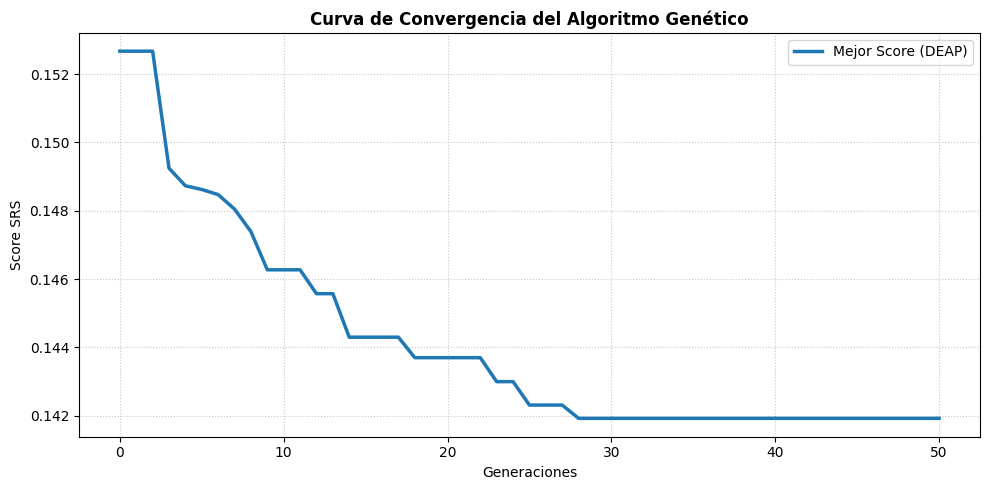

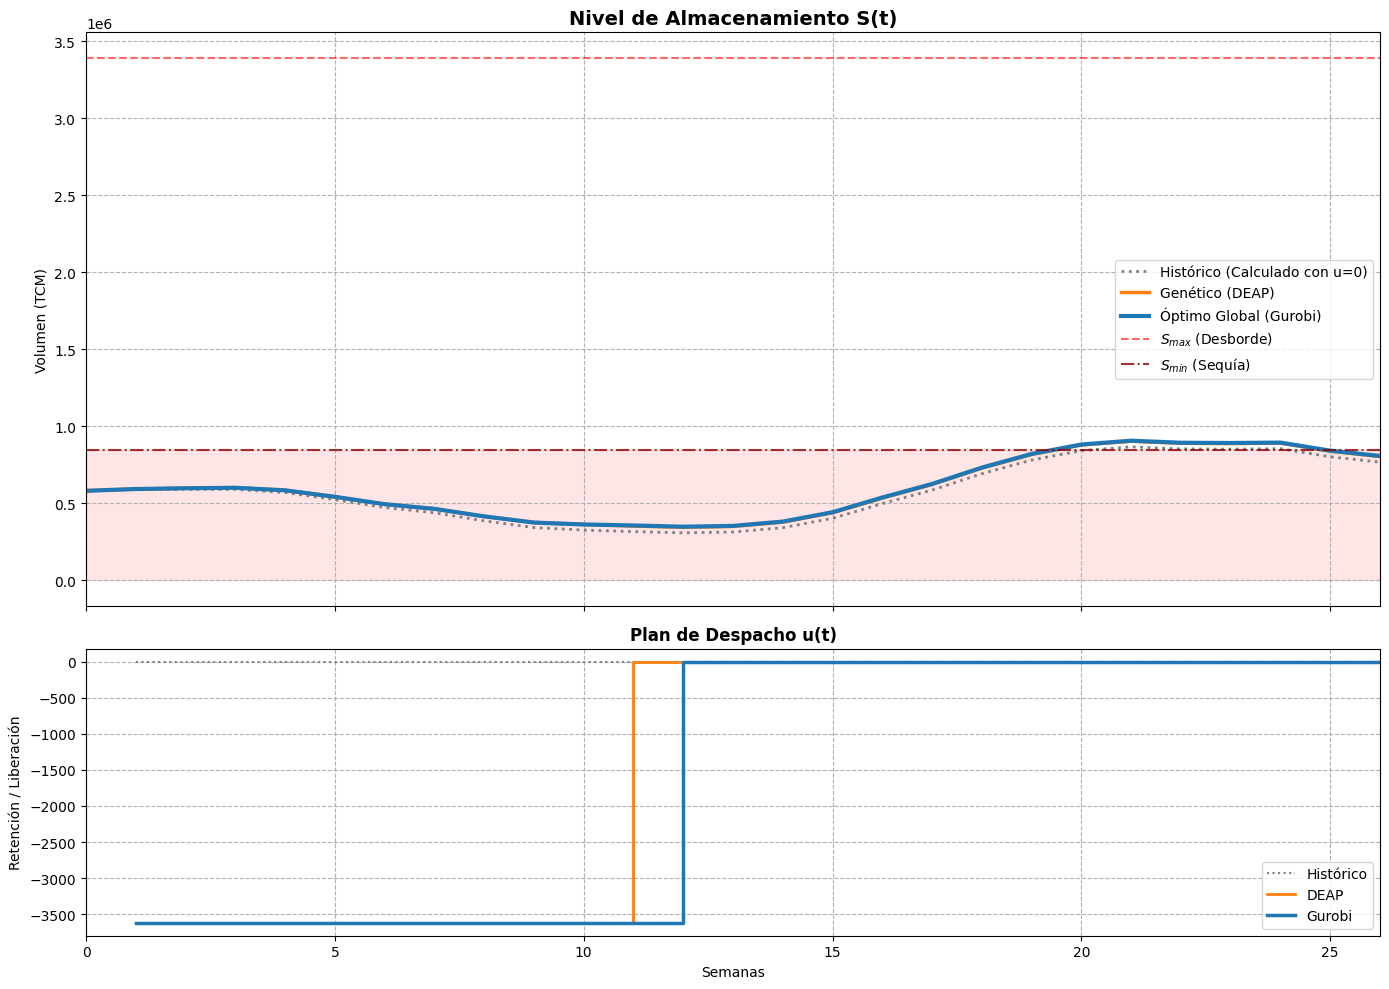

In [ ]:
# =========================================================
# REQUISITOS DE INSTALACIÓN:
# !pip install deap gurobipy numpy matplotlib pandas scipy
# =========================================================

import time
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Librerías de Optimización
from deap import base, creator, tools, algorithms
import gurobipy as gp
from gurobipy import GRB

# =========================================================
# 1. CARGA DE DATOS REALES
# =========================================================
print("📥 Cargando datasets históricos...")
# Asegúrate de que los archivos estén en el mismo directorio que el script
try:
    df_lib = pd.read_excel("R_observ.xlsx")
    df_cambio = pd.read_csv("Cambio_almacenamiento_historico.csv")
    df_total = pd.read_csv("DataSetExport-Total Storage.csv")
except Exception as e:
    print(f"❌ Error al cargar los archivos: {e}")
    print("Asegúrate de que los archivos Excel y CSV estén en la misma carpeta.")
    exit()


# =========================================================
# 2. PREPARACIÓN Y LIMPIEZA (ETL)
# =========================================================
def preparar_ventana_semanal(df_lib, df_cambio, df_total, fecha_inicio_str, semanas):
    """
    Procesa y limpia los datos históricos para generar el horizonte de planeación.
    """
    dataframes = [df_lib.copy(), df_cambio.copy(), df_total.copy()]
    for i, df in enumerate(dataframes):
        df.columns = df.columns.str.strip()
        if 'Timestamp (UTC-06:00)' in df.columns:
            df.rename(columns={'Timestamp (UTC-06:00)': 'Fecha'}, inplace=True)

        if 'Fecha' in df.columns:
            df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')
            df = df.dropna(subset=['Fecha']).set_index('Fecha')
        dataframes[i] = df

    df_lib_p, df_cambio_p, df_total_p = dataframes

    # Agrupación Semanal
    lib_semanal = df_lib_p['Valor'].resample('W-SUN').mean() * 604.8
    cambio_semanal = df_cambio_p['Value (TCM)'].resample('W-SUN').sum()
    total_semanal = df_total_p['Value (TCM)'].resample('W-SUN').first()

    # Extracción de ventana temporal
    fecha_inicio = pd.to_datetime(fecha_inicio_str)
    R_obs = lib_semanal.loc[fecha_inicio:].head(semanas).values
    Delta_S_obs = cambio_semanal.loc[fecha_inicio:].head(semanas).values

    # Condición Inicial (Último registro válido antes o durante el inicio)
    S_inicial = total_semanal.loc[:fecha_inicio].iloc[-1]

    return R_obs, Delta_S_obs, S_inicial


# =========================================================
# 3. PARÁMETROS DEL MODELO GLOBAL
# =========================================================
T = 26
fecha_inicio_str = '2024-01-01'  # Fecha del año de sequía para el benchmark

# Extraer vectores de datos reales
R_obs, Delta_S_obs, S_inicial = preparar_ventana_semanal(df_lib, df_cambio, df_total, fecha_inicio_str, T)

S_max = 3387000.0          # Capacidad máxima TCM
S_min = 0.25 * S_max       # Almacenamiento crítico (25%)
mediana_R = np.median(R_obs)
delta_u = 0.25 * mediana_R
u_max = 2 * delta_u

# Niveles discretos permitidos (Espacio Cuántico/Heurístico)
NIVELES_PERMITIDOS = [-2*delta_u, -delta_u, 0.0, delta_u, 2*delta_u]

# PONDERACIONES GLOBALES (Compartidas entre DEAP y Gurobi)
PESO_w1 = 1 / ((T + 1) * (S_min**2))
PESO_w2 = 0.1 / (T * (u_max**2))
PESO_w3 = 0.1 / ((T - 1) * ((2 * u_max)**2))


# =========================================================
# NUEVO: VISUALIZACIÓN DE VARIABLES CALCULADAS
# =========================================================
def visualizar_variables_calculadas():
    """
    Imprime un panel de control con el valor exacto de todas las
    variables, parámetros y pesos calculados antes de optimizar.
    """
    print("\n" + "═"*65)
    print(" 📊 RESUMEN DE VARIABLES CALCULADAS (DATASETS REALES)")
    print("═"*65)
    print(f"Horizonte de Planeación (T) : {T} semanas")
    print(f"Fecha de Inicio             : {fecha_inicio_str}")

    print("\n[ PARÁMETROS FÍSICOS DE LA PRESA ]")
    print(f"Capacidad Máxima (S_max)    : {S_max:,.2f} TCM")
    print(f"Límite de Sequía (S_min)    : {S_min:,.2f} TCM")
    print(f"Volumen Inicial (S_inicial) : {S_inicial:,.2f} TCM")

    print("\n[ ESPACIO DE DECISIÓN (HEURÍSTICO / CUÁNTICO) ]")
    print(f"Mediana del Flujo Histórico : {mediana_R:,.2f} TCM")
    print(f"Salto Base (delta_u)        : {delta_u:,.2f} TCM")
    print(f"Ajuste Máximo Permitido     : {u_max:,.2f} TCM")
    print("Niveles Permitidos u(t)     : [", ", ".join([f"{x:,.2f}" for x in NIVELES_PERMITIDOS]), "]")

    print("\n[ PONDERACIONES DE LA FUNCIÓN OBJETIVO (SRS) ]")
    print(f"Peso de Zona Crítica (w1)   : {PESO_w1:.12e}")
    print(f"Peso de Desviación (w2)     : {PESO_w2:.12e}")
    print(f"Peso de Suavidad (w3)       : {PESO_w3:.12e}")

    print("\n[ VISTAZO A LOS VECTORES DE DATOS (Primeras 5 semanas) ]")
    print(f"Liberaciones (R_obs)        : {np.round(R_obs[:5], 2)} ...")
    print(f"Cambios Vol (Delta_S_obs)   : {np.round(Delta_S_obs[:5], 2)} ...")
    print("═"*65 + "\n")


# =========================================================
# 4. CONFIGURACIÓN DEL ALGORITMO GENÉTICO (DEAP)
# =========================================================
if 'FitnessMin' in creator.__dict__: del creator.FitnessMin
if 'Individual' in creator.__dict__: del creator.Individual

creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.FitnessMin)

toolbox = base.Toolbox()
toolbox.register("attr_level", random.choice, NIVELES_PERMITIDOS)
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_level, n=T)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

def evaluar_srs(individuo):
    cromosoma_u = np.array(individuo)
    S_opt = np.zeros(T + 1)
    S_opt[0] = S_inicial

    # Restricción Límite 10%
    if abs(np.sum(cromosoma_u)) > 0.10 * np.sum(R_obs):
        return (float('1e10'),)

    for t in range(T):
        S_opt[t+1] = S_opt[t] + Delta_S_obs[t] - cromosoma_u[t]
        # Límites Físicos Duros
        if R_obs[t] + cromosoma_u[t] < 0: return (float('1e10'),)
        if S_opt[t+1] < 0 or S_opt[t+1] > S_max: return (float('1e10'),)

    # Evaluación (t=1 a T+1 para alinear con MIQP)
    C_crit = np.sum([max(0, S_min - S_opt[t])**2 for t in range(1, T+1)])
    C_dev = np.sum(cromosoma_u**2)
    C_smooth = np.sum(np.diff(cromosoma_u)**2)

    SRS = (PESO_w1 * C_crit) + (PESO_w2 * C_dev) + (PESO_w3 * C_smooth)
    return (SRS,)

toolbox.register("evaluate", evaluar_srs)
toolbox.register("mate", tools.cxTwoPoint)

def mutar_nivel(individuo, indpb):
    for i in range(len(individuo)):
        if random.random() < indpb:
            individuo[i] = random.choice(NIVELES_PERMITIDOS)
    return individuo,

toolbox.register("mutate", mutar_nivel, indpb=0.15)
toolbox.register("select", tools.selTournament, tournsize=4)

def correr_modelo_deap():
    pop = toolbox.population(n=200)
    pop[0] = creator.Individual([0.0] * T) # Seeding de ventaja

    hof = tools.HallOfFame(1)
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("min", np.min)
    stats.register("avg", np.mean)

    print("[DEAP] Iniciando evolución genética...")
    pop, log = algorithms.eaSimple(pop, toolbox, cxpb=0.7, mutpb=0.2, ngen=50,
                                   stats=stats, halloffame=hof, verbose=False)

    mejor_solucion = hof[0]
    score_final = mejor_solucion.fitness.values[0]

    print("="*50)
    print(f"✅ RESULTADOS DEAP | Mejor Score (SRS): {score_final:.6f}")
    print("Secuencia Óptima de Ajustes u(t) [DEAP]:")
    print(np.round(np.array(mejor_solucion), 2))
    print("="*50)

    return pop, log, hof, np.array(mejor_solucion)


# =========================================================
# 5. CONFIGURACIÓN DEL SOLUCIONADOR EXACTO (GUROBI MIQP)
# =========================================================
def resolver_benchmark_gurobi(R_obs, Delta_S_obs, S_inicial, S_max, S_min, delta_u, w1, w2, w3):
    print("\n[GUROBI] Iniciando optimización matemática exacta (MIQP)...")
    limite_10_pct = 0.10 * np.sum(R_obs)

    env = gp.Env(empty=True)
    env.setParam("OutputFlag", 0)
    env.start()
    m = gp.Model("Orquestador_MIQP", env=env)

    x = m.addVars(T, vtype=GRB.INTEGER, lb=-2, ub=2, name="x")
    u = m.addVars(T, vtype=GRB.CONTINUOUS, lb=-GRB.INFINITY, name="u")
    S = m.addVars(T + 1, vtype=GRB.CONTINUOUS, lb=0, ub=S_max, name="S")
    abs_u = m.addVars(T, vtype=GRB.CONTINUOUS, name="abs_u")
    deficit_S = m.addVars(T, vtype=GRB.CONTINUOUS, name="deficit_S")

    m.addConstr(S[0] == S_inicial, "CondInicial")

    for t in range(T):
        m.addConstr(u[t] == x[t] * delta_u, f"Ajuste_{t}")
        m.addConstr(S[t+1] == S[t] + Delta_S_obs[t] - u[t], f"Balance_{t}")
        m.addConstr(R_obs[t] + u[t] >= 0, f"Flujo_{t}")
        m.addConstr(abs_u[t] >= u[t], f"AbsPos_{t}")
        m.addConstr(abs_u[t] >= -u[t], f"AbsNeg_{t}")
        m.addConstr(deficit_S[t] >= S_min - S[t+1], f"DeficitCalc_{t}")
        m.addConstr(deficit_S[t] >= 0, f"DeficitPos_{t}")

    m.addConstr(gp.quicksum(abs_u[t] for t in range(T)) <= limite_10_pct, "Limite_Dev")

    C_crit = gp.quicksum(deficit_S[t] * deficit_S[t] for t in range(T))
    C_dev = gp.quicksum(u[t] * u[t] for t in range(T))
    C_smooth = gp.quicksum((u[t] - u[t-1]) * (u[t] - u[t-1]) for t in range(1, T))

    m.setObjective((w1 * C_crit) + (w2 * C_dev) + (w3 * C_smooth), GRB.MINIMIZE)
    m.optimize()

    if m.Status == GRB.OPTIMAL:
        secuencia_gurobi = np.array([u[t].X for t in range(T)])
        print("="*50)
        print(f"✅ RESULTADOS GUROBI | Mejor Score (SRS): {m.ObjVal:.6f}")
        print("Secuencia Óptima de Ajustes u(t) [Gurobi]:")
        print(np.round(secuencia_gurobi, 2))
        print("="*50)
        return secuencia_gurobi, m.ObjVal
    else:
        print(f"❌ Gurobi falló. Estado: {m.Status}")
        return None, None


# =========================================================
# 6. HERRAMIENTAS DE AUDITORÍA Y VISUALIZACIÓN
# =========================================================
def auditar_restricciones(secuencia_u, R_obs, Delta_S_obs, S_inicial, S_max, niveles_permitidos):
    print("\n" + "═"*55)
    print(" 🔎 AUDITORÍA DE RESTRICCIONES (COMPLIANCE CHECK)")
    print("═"*55)
    S_opt = np.zeros(T + 1)
    S_opt[0] = S_inicial
    fallos = 0

    niveles_validos = all(np.isclose(u, niveles_permitidos, atol=1e-5).any() for u in secuencia_u)
    print(f"[1] Niveles de decisión discretos  : {'✅ PASÓ' if niveles_validos else '❌ FALLÓ'}")
    if not niveles_validos: fallos += 1

    desviacion_total = abs(np.sum(secuencia_u))
    limite_10_porciento = 0.10 * np.sum(R_obs)
    balance_valido = desviacion_total <= limite_10_porciento
    print(f"[2] Balance Acumulado (Límite 10%) : {'✅ PASÓ' if balance_valido else '❌ FALLÓ'}")
    if not balance_valido: fallos += 1

    flujo_negativo, desborde, sequia = False, False, False
    for t in range(T):
        if R_obs[t] + secuencia_u[t] < 0: flujo_negativo = True
        S_opt[t+1] = S_opt[t] + Delta_S_obs[t] - secuencia_u[t]
        if S_opt[t+1] > S_max: desborde = True
        if S_opt[t+1] < 0: sequia = True

    print(f"[3] No-negatividad del flujo       : {'❌ FALLÓ' if flujo_negativo else '✅ PASÓ'}")
    print(f"[4] Límite inferior (S >= 0)       : {'❌ FALLÓ' if sequia else '✅ PASÓ'}")
    print(f"[5] Límite superior (S <= S_max)   : {'❌ FALLÓ' if desborde else '✅ PASÓ'}")
    print("-" * 55)
    print("🚀 DICTAMEN: SOLUCIÓN FACTIBLE" if fallos == 0 else f"⚠️ DICTAMEN: SOLUCIÓN INVIABLE ({fallos} errores)")
    print("═"*55 + "\n")


def graficar_convergencia(logbook):
    generaciones = logbook.select("gen")
    min_fitness = logbook.select("min")
    plt.figure(figsize=(10, 5))
    plt.plot(generaciones, min_fitness, label="Mejor Score (DEAP)", color='#1f77b4', linewidth=2.5)
    plt.title("Curva de Convergencia del Algoritmo Genético", fontweight='bold')
    plt.xlabel("Generaciones")
    plt.ylabel("Score SRS")
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.show()


def graficar_comparativa_estrategias(Delta_S_obs, S_inicial, S_max, S_min, u_deap, u_gurobi):
    semanas_S = np.arange(T + 1)
    semanas_u = np.arange(1, T + 1)

    def simular_embalse(secuencia_u):
        S = np.zeros(T + 1)
        S[0] = S_inicial
        for t in range(T): S[t+1] = S[t] + Delta_S_obs[t] - secuencia_u[t]
        return S

    S_historico = simular_embalse(np.zeros(T))
    S_deap = simular_embalse(u_deap)
    S_gurobi = simular_embalse(u_gurobi)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

    # Subplot 1
    ax1.plot(semanas_S, S_historico, label='Histórico (Calculado con u=0)', color='gray', linestyle=':', linewidth=2)
    ax1.plot(semanas_S, S_deap, label='Genético (DEAP)', color='#ff7f0e', linewidth=2.5)
    ax1.plot(semanas_S, S_gurobi, label='Óptimo Global (Gurobi)', color='#1f77b4', linewidth=3)
    ax1.axhline(S_max, color='red', linestyle='--', alpha=0.6, label='$S_{max}$ (Desborde)')
    ax1.axhline(S_min, color='darkred', linestyle='-.', alpha=0.8, label='$S_{min}$ (Sequía)')
    ax1.fill_between(semanas_S, 0, S_min, color='red', alpha=0.1)
    ax1.set_title("Nivel de Almacenamiento S(t)", fontweight='bold', fontsize=14)
    ax1.set_ylabel("Volumen (TCM)")
    ax1.legend()
    ax1.grid(True, linestyle='--')

    # Subplot 2
    ax2.step(semanas_u, np.zeros(T), label='Histórico', color='gray', linestyle=':', where='post')
    ax2.step(semanas_u, u_deap, label='DEAP', color='#ff7f0e', linewidth=2, where='post')
    ax2.step(semanas_u, u_gurobi, label='Gurobi', color='#1f77b4', linewidth=2.5, where='post')
    ax2.set_title("Plan de Despacho u(t)", fontweight='bold', fontsize=12)
    ax2.set_xlabel("Semanas")
    ax2.set_ylabel("Retención / Liberación")
    ax2.legend()
    ax2.grid(True, linestyle='--')

    plt.xlim(0, T)
    plt.tight_layout()
    plt.show()


# =========================================================
# 7. ORQUESTADOR MAESTRO (DISPARADOR)
# =========================================================
if __name__ == "__main__":

    # PASO 0: VISUALIZAR VARIABLES
    visualizar_variables_calculadas()

    print("🚀 INICIANDO PIPELINE DE ORQUESTACIÓN HÍDRICA...\n")

    # 1. DEAP
    inicio_deap = time.time()
    pop, log, hof, seq_deap = correr_modelo_deap()
    print(f"⏱️ Tiempo procesamiento DEAP: {time.time() - inicio_deap:.2f} segundos.")

    # 2. GUROBI
    inicio_gurobi = time.time()
    seq_gurobi, score_gurobi = resolver_benchmark_gurobi(
        R_obs, Delta_S_obs, S_inicial, S_max, S_min, delta_u,
        w1=PESO_w1, w2=PESO_w2, w3=PESO_w3
    )
    print(f"⏱️ Tiempo procesamiento Gurobi: {time.time() - inicio_gurobi:.2f} segundos.")

    # 3. AUDITORÍA
    auditar_restricciones(seq_deap, R_obs, Delta_S_obs, S_inicial, S_max, NIVELES_PERMITIDOS)

    # 4. VISUALIZACIONES
    print("📊 Generando visualizaciones comparativas...")
    graficar_convergencia(log)
    if seq_gurobi is not None:
        graficar_comparativa_estrategias(Delta_S_obs, S_inicial, S_max, S_min, seq_deap, seq_gurobi)